# Mobilenet V3 @ CBAM with MFSA
> **CBAM** - Convolutional Block Attention Module.
> 
> Contains:
>  - Channel Attention (Squeeze and Excite Block)
>  - Spatial Attention

> **MFSA** - Multi-Filter Spatial Attention
> - Instead of using single filter as Spatial Attention Score - we use num_filter == num_channel
> - Step 1 : Channel Wise Average and Channel Wise Max Pooling
> - Step 2 : Attention Map using Depthwise Separable Conv2D with Kernel Size atleast 5

> **Subspace FC Bottleneck Layer**
> - Instead of using Fully Connected layer to Global pooled feature vector - we apply FC to subspace of the feature vector
> - i.e. Mobilenet feature vector size is 576 (before MobileNet FC layer) - we group feature vector to 9 sub spaces giving us vector of 64 per sub space. We then apply Dense bottleneck layer to each sub space 64 -> 128 -> 256 -> 128; giving us final feature vector of size 1152. This avoid exploding parameter size. 

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import random
import os
import shutil

2025-06-15 12:56:03.058010: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-15 12:56:03.058132: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-15 12:56:03.192602: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Configurations

In [2]:
DEVICE = 'GPU:0' if len(tf.config.list_physical_devices('GPU')) else 'CPU:0'

################################
###### Configurations #########
##############################
seed = 999
SEED = seed
USE_DETERMINISTIC = True
K_FOLD_INDEX = 1
oversampling = 0 # How many times are we gonna over sample

## Model Configurations
MODEL_NAME="T0_MobileNetV3S_CBAM_MFSA-Exp5-KF1.keras"
IMG_SIZE=(224,224,3)
MODEL_TYPE = 'S' ## Mobilenet V3 - 'S' : Small; 'L': Large - default 'S'
FUSION_TYPE = 'add' ## feature fusion [mobilenet output && CBAM output ] - 'average', 'add', 'None' : Concatenate - default 'average'
POOLER_PLACEMENT = None ## Mobilenet Pooler Placement respective to fusion - 'before', 'after', 'None' : Pooler unused - default 'after'
CBAM_ORDER = 'normal' ## Originally in CBAM channel attention precedes spatial attention - 'normal', 'inverted' - default 'normal'
### Apparently CBAM_ORDER do not have much effect on the output --- So no need to use inverted. [check output of Version 2 & 3]

## Training Configurations
BATCH_SIZE=32
EPOCHS = 300
ES_PATIENCE = 13 ## Patience Epoch for Early Stopping
ES_MONITOR = 'val_loss'
LR_REDUCTION_FACTOR = 0.8 ## for ReduceLROnPlateau Callback
LR_REDUCTION_PATIENCE = 3 ## Patience for LR Reduction
LR_REDUCTION_MONITOR = 'val_loss'

##### FineTuning Part
INIT_LR1 = 2e-4 ## Initial Learning Rate (AdamW) 
W_DECAY1 = 5e-2 ## Weight Decay
MIN_LR1 = 1e-6 ## Minimum Learning Rate for ReduceLROnPlateau Callback

USE_WARMUP = False
WARMUP_EPOCH = 10
WARMUP_INIT_LR = INIT_LR1 / WARMUP_EPOCH
WARMUP_MAX_LR = INIT_LR1
WARMUP_INCREMENT_RATE = 0.5
##### Base Model Freezing Part
INIT_LR2 = 2e-5 # Initial Learning Rate for optimizer (AdamW)
W_DECAY2 = 5e-5 ## Weight Decay for optimizer
MIN_LR2 = 1e-9 # Minimum Learning Rate for ReduceLROnPlateau


def seedEverything(seed, deterministic = False):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)

    if deterministic:
        tf.config.experimental.enable_op_determinism()

        os.environ['TF_DETERMINISTIC_OPS'] = '1'
        os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

        tf.config.threading.set_inter_op_parallelism_threads(2)
        tf.config.threading.set_intra_op_parallelism_threads(2)


seedEverything(seed, USE_DETERMINISTIC)
tf.__version__

'2.15.0'

In [3]:
## Downloading DeepWeeds Data  ## For Google Colab
# url = 'https://drive.google.com/uc?export=download&id=1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj'
# !gdown 1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj
# !unzip -qq images.zip -d images

In [4]:
# data_info = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/labels.csv') ## for GoogleColab
data_info = pd.read_csv("/kaggle/input/deepweeds/labels.csv") ## For Kaggle
data_info

,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple
...,...,...,...
17504,20180322-133822-1.jpg,8,Negative
17505,20180322-133832-1.jpg,8,Negative
17506,20180322-133840-1.jpg,8,Negative
17507,20180322-133850-1.jpg,8,Negative


In [5]:
data_info[['Species','Label']].groupby(by='Species').count().T

Species,Chinee apple,Lantana,Negative,Parkinsonia,Parthenium,Prickly acacia,Rubber vine,Siam weed,Snake weed
Label,1125,1064,9106,1031,1022,1062,1009,1074,1016


In [6]:
label2id = data_info[['Species','Label']].groupby(by='Species').min().to_dict()['Label']
id2label = {label2id[i]:i for i in label2id}
id2label

{0: 'Chinee apple',
 1: 'Lantana',
 8: 'Negative',
 2: 'Parkinsonia',
 3: 'Parthenium',
 4: 'Prickly acacia',
 5: 'Rubber vine',
 6: 'Siam weed',
 7: 'Snake weed'}

In [7]:
low_data_labels = data_info[data_info['Species'] != "Negative"]['Label'].unique() ## labels with very low data
low_data_labels

array([0, 1, 7, 6, 4, 3, 5, 2])

# Splitting Data into Train:Valid:Test Splits (60:20:20)

In [8]:
# colabAI prompt: train test split using data_info
from sklearn.model_selection import train_test_split, StratifiedKFold

### K-Fold Validation-----
#####---------------------
split_index = K_FOLD_INDEX # index to retrieve
print("Using KFold: Index",split_index+1,"out of 5 folds")
print("-------------------------------------------------\n")

# skfold = StratifiedKFold()
# kSplits = skfold.split(data_info['Filename'], y=data_info['Label'])

# for index in range(skfold.get_n_splits()):
#     train_index, test_index = next(kSplits)
#     if index == split_index:
#         break

# trax, tex, tray, tey = train_test_split(data_info['Filename'],data_info['Label'], test_size=0.4, random_state=seed)
# train_data = pd.DataFrame({"Filename":trax,"label":tray})

# trax, tex, tray, tey = train_test_split(tex,tey, test_size=0.5, random_state=seed)
# valid_data = pd.DataFrame({"Filename":trax,"label":tray})
# test_data = pd.DataFrame({"Filename":tex,"label":tey})

Using KFold: Index 2 out of 5 folds
-------------------------------------------------



In [9]:
train_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/train_subset{}.csv'.format(split_index)) ## for GoogleColab
train_data.rename(columns={"Label":"label"}, inplace=True)

valid_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/val_subset{}.csv'.format(split_index)) ## for GoogleColab
valid_data.rename(columns={"Label":"label"}, inplace=True)
test_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/test_subset{}.csv'.format(split_index)) ## for GoogleColab
test_data.rename(columns={"Label":"label"}, inplace=True)

print("Is There Duplicates: ", not valid_data[valid_data['Filename'].isin(test_data['Filename'])].empty)
print("Train Data\n--------\n",train_data.groupby(by='label').count().T, "\tTotal:", train_data.shape)
print("Validation Data\n--------\n",valid_data.groupby(by='label').count().T, "\tTotal:", valid_data.shape)
print("Test Data\n--------\n",test_data.groupby(by='label').count().T, "\tTotal:", test_data.shape)

Is There Duplicates:  False
Train Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  676  637  619  613  637  605  644  610  5463 	Total: (10504, 2)
Validation Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  225  213  206  204  212  202  215  203  1822 	Total: (3502, 2)
Test Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  225  213  206  205  213  202  215  203  1821 	Total: (3503, 2)


# Helper Functions

- Organize Images to Directory as per Label for Creating Generator (organize_data_to_directory)
- Dataset Generator (getDatasetGenerators) - works in tandem with "organize_data_to_directory"
- Class Weights For Imbalanced Dataset (getWeightedClass)
- Accuracy / Loss plot (plot_loss_acc)
- Evaluation Metrics Calculation (eval_model, print_stats, calcFalseRate)
- Prediction with Threshold as used by DeepWeeds Author (prediction_argmax)



In [10]:
from tqdm.auto import tqdm

def organize_data_to_directory(data_info,source_dir='',target_dir='',oversample=0,oversampling_labels=[]):
    for index, row in tqdm(data_info.iterrows()):
        filename = row['Filename']
        label = row['label']

        source = os.path.join(source_dir,filename)

        #if not os.path.exists(source):
        #    print("File Doesn't Exist", source)
        #    continue

        target_path = os.path.join(target_dir,str(label))
        target = os.path.join(target_path,filename)
        # print(source,target)

        if not os.path.exists(target_path):
            os.mkdir(target_path)

        if not os.path.exists(target):
            if oversample and (label in oversampling_labels):
                for i in range(oversample):
                    sample_filename = os.path.join(target_path, "oversample-"+str(i)+"-"+filename)
                    shutil.copy(source, sample_filename)

            shutil.copy(source,target)

##-----------------------------
###----------------------------

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory

def getDatasetGenerators(train_dir, **kwargs):
    # --------------------
    # Flow training images in batches using generator
    # --------------------
    generator = image_dataset_from_directory(
        train_dir,
        **kwargs
    )

    return generator

In [11]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

def prediction_argmax(prediction, rand_guess=1):
    prediction = np.asarray(prediction)
    l_pred = np.argmax(prediction[low_data_labels])
    if(prediction[l_pred] > rand_guess):
        return l_pred

    return np.argmax(prediction)

def calcFalsePositiveRate(a_label, p_label, label_names=None, n_class=None):
    if n_class is None:
        n_class = len(np.unique(a_label))
    conf_mat = tf.math.confusion_matrix(a_label, p_label, num_classes=n_class).numpy()

    false_rate = []
    total = len(a_label)
    for i in range(n_class):
        tP = conf_mat[i][i]
        fN = np.sum(conf_mat[i,:]) - tP

        fP = np.sum(conf_mat[:,i]) - tP
        tN = total - (tP + fN + fP)

        fP_Rate = fP/(tN+fP)
        # fN_Rate = fN/(tP+fN)
        accuracy = tP / (tP+fN)

        false_rate.append((fP_Rate,accuracy))

    false_rate = pd.DataFrame(false_rate, columns=["False Positive Rate", "Accuracy"], index=label_names)
    return false_rate

def printStats(actual_labels,prediction, use_rand_guess= 0):
    if use_rand_guess:
        prediction = [prediction_argmax(x, rand_guess=use_rand_guess) for x in prediction]
    else:
        prediction = [np.argmax(x) for x in prediction]

    print("Evaluation Metrics\n=================================\n")
    #     print("F1-Score",f1_score(actual_labels,prediction,average='weighted'))
    #     print("Precision-Score",precision_score(actual_labels,prediction,average='weighted'))
    #     print("Recall-Score",recall_score(actual_labels,prediction,average='weighted'))
    #     print("accuracy_Score",accuracy_score(actual_labels,prediction))

    label_names = [id2label[i] for i in range(len(id2label))]
    print(classification_report(actual_labels, prediction,digits=5, target_names=label_names))
    print()
    print(calcFalsePositiveRate(actual_labels, prediction, label_names = label_names))
    print()
    print("Confusion Matrix\n=================================\n")
    n_class = np.unique(actual_labels).shape[0]
    cmd = ConfusionMatrixDisplay.from_predictions(
        actual_labels, prediction,
        display_labels=label_names,
        xticks_rotation=45 #'vertical'
    )
    #cmd.plot()
    plt.show()

def eval_model(model, data_gen, use_rand_guess=False):
    print("model.evaluate")
    model.evaluate(data_gen)
    
    print("model.predict")
    actual_labels = []
    pred_prob = []
    for batch in tqdm(data_gen):
        actual_labels.extend([np.argmax(z) for z in batch[1]])
        pred_prob.extend(list(model(batch[0], training=False)))

    printStats(actual_labels,pred_prob,use_rand_guess)
    return actual_labels, pred_prob


def plot_loss_acc(history):
    '''Plots the training and validation loss and accuracy from a history object'''
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']
    if 'peaks' in history:
        peaks = history['peaks']
    else:
        _min = np.argmin(val_loss)
        peaks = [_min]

    epochs = range(len(acc))
    print("Total Epochs:",epochs)

    plt.figure(figsize=[16, 4])
    plt.subplot(1,2,1)
    p_value = [val_acc[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, acc, label='Training accuracy', color='red')
    plt.plot(epochs, val_acc, label='Validation accuracy', color='magenta')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    p_value = [val_loss[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, loss, label='Training Loss', color='red')
    plt.plot(epochs, val_loss, label='Validation Loss', color='magenta')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

# Creating Dateset ImageGenerator

In [12]:
if oversampling:
    print("Oversampling",oversampling,"times for labels",low_data_labels)
else:
    print("No OverSampling")

# base_dir = '/content/dataset_9c' ## For GoogleColab
# input_dir = '/content/images' ## For GoogleColab

input_dir = "/kaggle/input/deepweeds/images" ## For Kaggle
base_dir = "/kaggle/working/deepweeds_9c" ## For Kaggle

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

os.mkdir(base_dir)
os.mkdir(train_dir)
os.mkdir(validation_dir)
os.mkdir(test_dir)

## Organizing Training Data
organize_data_to_directory(train_data, source_dir=input_dir, target_dir=train_dir, oversample=oversampling, oversampling_labels=low_data_labels)

# ## Organizing Validation Data
organize_data_to_directory(valid_data, source_dir=input_dir, target_dir=validation_dir)

# ## Organizing Test Data
organize_data_to_directory(test_data, source_dir=input_dir, target_dir=test_dir)

No OverSampling


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [13]:
train_generator = getDatasetGenerators(
      train_dir,
      batch_size=BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

validation_generator = getDatasetGenerators(
      validation_dir,
      batch_size=BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

test_generator = getDatasetGenerators(
      test_dir,
      batch_size=BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=False
)

Found 10504 files belonging to 9 classes.
Found 3502 files belonging to 9 classes.
Found 3503 files belonging to 9 classes.


# Sample Images

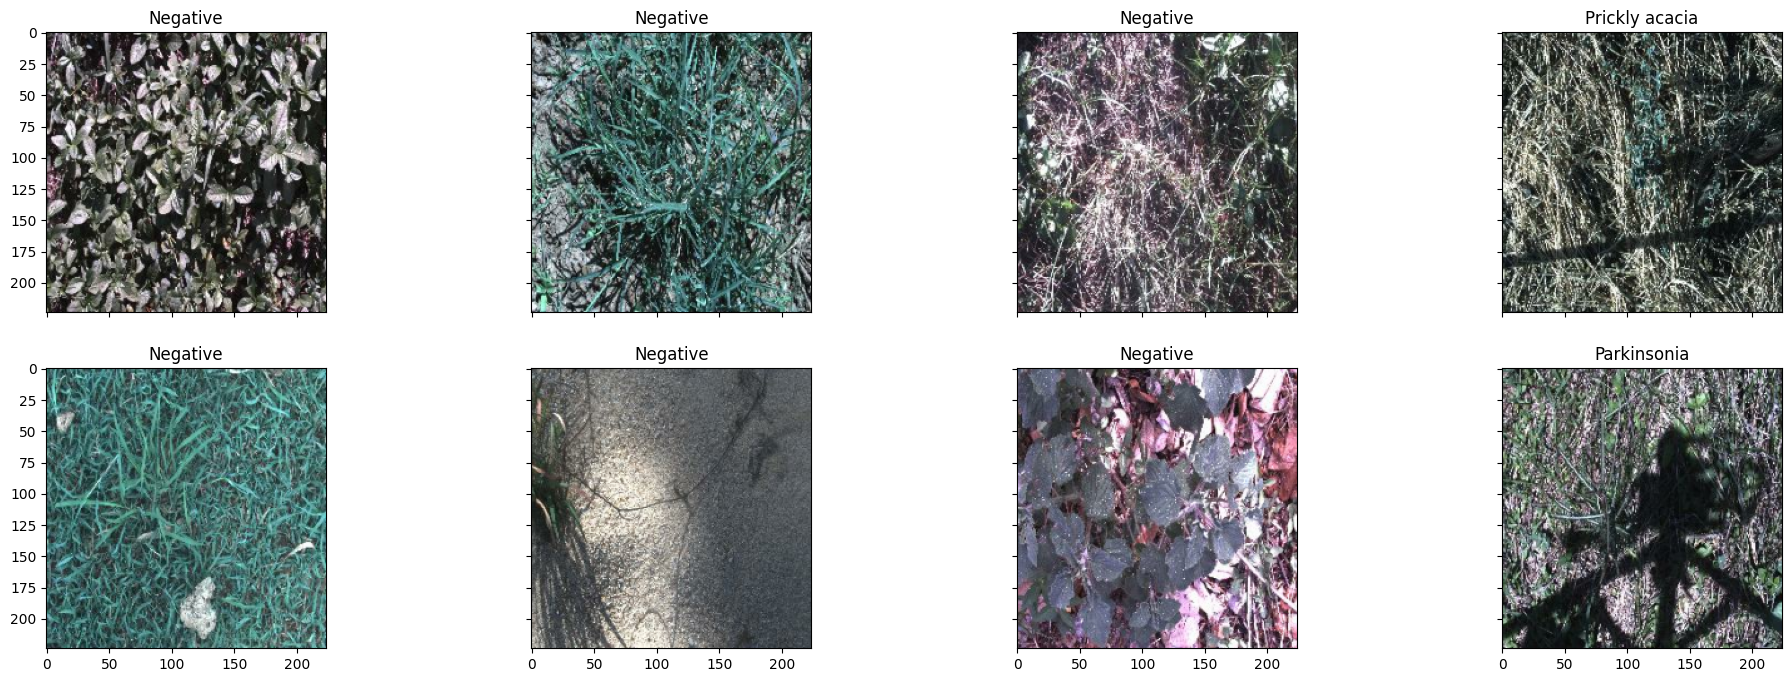

In [14]:
#image visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 4, sharex=True, sharey=True, figsize=(24,8))

for images, labels in validation_generator:
    for i in range(2):
        for j in range(4):
            ax[i][j].imshow(images[i+j*2].numpy().astype(np.int32))
            ax[i][j].set_title(id2label[np.argmax(labels[i+j*2])])

    break
plt.show()

In [15]:
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.layers as layers
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, MaxPool2D, Reshape, \
                        Dense, multiply, Permute, Concatenate, Conv2D, Add, Activation, Lambda, Average
from tensorflow.keras import backend as K
from tensorflow.keras.activations import sigmoid, softmax

class ChannelWiseMaxPool(tf.keras.layers.Layer):
    def __init__(self,pool_size=2,stride=None,padding='valid',data_format='channels_last', **kwargs):
        super(ChannelWiseMaxPool,self).__init__(**kwargs)
        self.pool_size = pool_size
        self.stride = stride
        self.padding = padding
        if stride is None:
            self.stride = self.pool_size

        self.data_format = 'channels_last' if data_format == 'channels_first' else 'channels_first'
        self.max = tf.keras.layers.MaxPool1D(self.pool_size, self.stride, padding=self.padding, data_format=self.data_format)

    def build(self,input_shape):
        self.reshape_forward = tf.keras.layers.Reshape((-1,input_shape[-1]))
        self.reshape_backward= tf.keras.layers.Reshape((input_shape[1], input_shape[2], -1))

    def call(self,x):
        x = self.reshape_forward(x)
        x = self.max(x)
        x = self.reshape_backward(x)
        return x


class ChannelWiseAvgPool(tf.keras.layers.Layer):
    def __init__(self,pool_size=2,stride=None,padding='valid',data_format='channels_last', **kwargs):
        super(ChannelWiseAvgPool,self).__init__(**kwargs)
        self.pool_size = pool_size
        self.stride = stride
        self.padding = padding
        if stride is None:
            self.stride = self.pool_size

        ## data_format parameter is of 2D Image, hence for 1D pool across channel have to reverse the data_format.
        self.data_format = 'channels_last' if data_format == 'channels_first' else 'channels_first'
        self.avg = tf.keras.layers.AveragePooling1D(self.pool_size, self.stride, padding=self.padding, data_format=self.data_format)

    def build(self,input_shape):
        self.reshape_forward = tf.keras.layers.Reshape((-1,input_shape[-1]))
        self.reshape_backward= tf.keras.layers.Reshape((input_shape[1], input_shape[2], -1))

    def call(self,x):
        x = self.reshape_forward(x)
        x = self.avg(x)
        x = self.reshape_backward(x)
        return x

class ChannelWiseConvolution(tf.keras.layers.Layer):
    def __init__(self, channel_conv_filters, channel_conv_kernel_size=16, channel_conv_strides=8, channel_conv_padding='same', channel_conv_activation=None, data_format='channels_last', **kwargs):
        super(ChannelWiseConvolution,self).__init__(**kwargs)
        
        ## data_format parameter is of 2D Image, hence for 1D pool across channel have to reverse the data_format.
        self.data_format = 'channels_last' if data_format == 'channels_first' else 'channels_first'
        self.channel_conv = tf.keras.layers.Conv1D(filters = channel_conv_filters, kernel_size=channel_conv_kernel_size, strides=channel_conv_strides, padding=channel_conv_padding, activation=channel_conv_activation, use_bias=False, data_format=self.data_format)
      
    def build(self,input_shape):
        self.reshape_forward = tf.keras.layers.Reshape((-1, input_shape[-1]))
        self.reshape_backward= tf.keras.layers.Reshape((input_shape[1], input_shape[2], -1))

    def call(self,x):
        x = self.channel_conv(self.reshape_forward(x))
        x = self.reshape_backward(x)
        return x


def GlobalAverageOfMaximums(x, max_pool_size=2, layer_num=1, keep_out_dims=False):
    _max = layers.MaxPooling2D(pool_size=max_pool_size,padding='same', name="Maximums_L{}".format(layer_num))(x)
    _avg = layers.GlobalAveragePooling2D(name="Average_of_Maximums_L{}".format(layer_num), keepdims=keep_out_dims)(_max)
    return _avg

In [16]:
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, MaxPool2D, Reshape, \
Dense, multiply, Permute, Concatenate, Conv2D, Add, Activation, Lambda, Average
from tensorflow.keras import backend as K
from tensorflow.keras.activations import sigmoid, softmax

def cbam_block(cbam_feature, ratio=8):
    """Contains the implementation of Convolutional Block Attention Module(CBAM) block.
    As described in https://arxiv.org/abs/1807.06521.
    """

    cbam_feature = channel_attention(cbam_feature, ratio)
    cbam_feature = spatial_attention(cbam_feature)
    return cbam_feature

def channel_attention(input_feature, ratio=8, seed=42, layer_num=0):
    channel_axis = 1 if K.image_data_format() == "channels_first" else -1
    channel = input_feature.shape[channel_axis]

    shared_layer_one = Dense(channel//ratio,
                             activation='relu',
                             kernel_initializer=keras.initializers.HeUniform(seed),
                             use_bias=True,
                             bias_initializer=keras.initializers.GlorotUniform(seed),
                           name=f'Dense_Squeeze_CA_{layer_num}')
    shared_layer_two = Dense(channel,
                             kernel_initializer=keras.initializers.HeUniform(seed),
                             use_bias=True,
                             bias_initializer=keras.initializers.GlorotUniform(seed),
                           name=f'Dense_Excite_CA_{layer_num}')

    avg_pool = GlobalAveragePooling2D(keepdims=True)(input_feature)
    assert avg_pool.shape[1:] == (1,1,channel)

    avg_pool = shared_layer_one(avg_pool)
    assert avg_pool.shape[1:] == (1,1,channel//ratio)

    avg_pool = shared_layer_two(avg_pool)
    assert avg_pool.shape[1:] == (1,1,channel)

    max_pool = GlobalMaxPooling2D(keepdims=True)(input_feature)
    assert max_pool.shape[1:] == (1,1,channel)

    max_pool = shared_layer_one(max_pool)
    assert max_pool.shape[1:] == (1,1,channel//ratio)

    max_pool = shared_layer_two(max_pool)
    assert max_pool.shape[1:] == (1,1,channel)

    cbam_feature = Add()([avg_pool,max_pool])
    cbam_feature = Activation('sigmoid')(cbam_feature)

    if K.image_data_format() == "channels_first":
        cbam_feature = Permute((3, 1, 2))(cbam_feature)

    return multiply([input_feature, cbam_feature])



def spatial_attention(input_feature, seed=42):
    kernel_size = 5

    if K.image_data_format() == "channels_first":
        channel = input_feature.shape[1]
        cbam_feature = Permute((2,3,1))(input_feature)
    else:
        channel = input_feature.shape[-1]
        cbam_feature = input_feature

    avg_pool = Lambda(lambda x: K.mean(x, axis=3, keepdims=True))(cbam_feature)
    assert avg_pool.shape[-1] == 1

    max_pool = Lambda(lambda x: K.max(x, axis=3, keepdims=True))(cbam_feature)
    assert max_pool.shape[-1] == 1

    concat = Concatenate(axis=3)([avg_pool, max_pool])
    assert concat.shape[-1] == 2

    cbam_feature = Conv2D(filters = 1,
                    kernel_size=kernel_size,
                    strides=1,
                    padding='same',
                    activation='sigmoid',
                    kernel_initializer=keras.initializers.HeUniform(seed),
                    use_bias=False)(concat)
    assert cbam_feature.shape[-1] == 1

    if K.image_data_format() == "channels_first":
        cbam_feature = Permute((3, 1, 2))(cbam_feature)

    return multiply([input_feature, cbam_feature])

In [17]:
import math
### MFSA
def MultiFilterSpatialAttention(input_feature, kernel_size=7, num_pooled_channel=4, seed=42, layer_num = 0):
    in_shape = input_feature.shape

    stride = in_shape[-1] // num_pooled_channel
    pool_size = (stride * 2)

    channel_avg = ChannelWiseAvgPool(pool_size, stride, padding='same', name='MFSA_CWAP_L{}'.format(layer_num))(input_feature)
    channel_max = ChannelWiseMaxPool(pool_size, stride, padding='same' , name='MFSA_CWMP_L{}'.format(layer_num))(input_feature)
    
    concat = Concatenate(axis=3)([channel_avg, channel_max])
    
    mfsa_feature = layers.Conv2D(filters = concat.shape[-1],
                    kernel_size=kernel_size,
                    strides=1,
                    padding='same',
                    # activation='sigmoid',
                    kernel_initializer=keras.initializers.HeUniform(seed),
                    use_bias=False,
                    groups=num_pooled_channel,
                    name="MFSA_Conv_L{}".format(layer_num))(concat)
    
    mfsa_feature = layers.Conv2D(in_shape[-1], 1, 1, 
                                 kernel_initializer=keras.initializers.HeUniform(seed), 
                                 use_bias=False, name="MFSA_ConvExpand_L{}".format(layer_num))(mfsa_feature)
    attn_score = layers.Activation('sigmoid')(mfsa_feature)
    
    return layers.Multiply(name="MFSA_Multiply_L{}".format(layer_num))([input_feature, attn_score])


def modified_cbam_block(cbam_feature, ratio=8, mfsa_kernel=7, mfsa_pool_size=32, seed=42, order='normal', layer_num=0):
    """Contains the implementation of Convolutional Block Attention Module(CBAM) block.
    As described in https://arxiv.org/abs/1807.06521.
    """
    if order == 'inverted':
        cbam_feature = MultiFilterSpatialAttention(cbam_feature, kernel_size=mfsa_kernel, num_pooled_channel=mfsa_pool_size, seed=seed, layer_num=layer_num)
        cbam_feature = channel_attention(cbam_feature, ratio, layer_num=layer_num, seed=seed)
    else:
        cbam_feature = channel_attention(cbam_feature, ratio, layer_num=layer_num, seed=seed)
        cbam_feature = MultiFilterSpatialAttention(cbam_feature, kernel_size=mfsa_kernel, num_pooled_channel=mfsa_pool_size, seed=seed, layer_num=layer_num)
        
    return cbam_feature

# Building MobileNet Model

In [18]:
from tensorflow.keras.applications import MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large
from tensorflow.keras.applications import EfficientNetV2S, ConvNeXtSmall

def augment(seed=42):
    return keras.Sequential([
        layers.RandomBrightness(0.3, (0, 1),seed=seed, name='RR_Bright'),
        # layers.RandomContrast(0.3, seed=seed, name='RR_Contr'), # can't run deterministically
        layers.RandomFlip(seed=seed, name='RR_Flip'),
        layers.RandomRotation(0.5, seed=seed, name='RR_Rot'),
        layers.RandomTranslation(0.4, 0.4, seed=seed, name='RR_Trans'),
        layers.RandomZoom(0.2, 0.2, seed=seed, name='RR_Zoom'),
        layers.GaussianDropout(0.01, seed=seed, name='RR_Gauss'),
    ], name='augment_pipeline')


def skipAugment(model):
    inputs = keras.Input(shape=IMG_SIZE)
    x = inputs
    for layer in model.layers:
        if 'augment' not in layer.name and 'input' not in layer.name:
            x = layer(x)

    model = keras.Model(inputs=inputs, outputs=x, name=model.name)
    return model


def hard_sigmoid(x):
    relu6 = layers.ReLU(max_value=6)
    return relu6(x + 3) / 6
    
def hard_swish(x):
    return x * hard_sigmoid(x)

def MobilenetV3Base(img_size, use='S'): # use = S (small) or L (large)
    # Load the MobileNet model with weights pre-trained on ImageNet.
    if(use=='S'):
        mobilenet = MobileNetV3Small(input_shape=img_size, weights='imagenet', include_preprocessing=False)
    if(use=='L'):
        mobilenet = MobileNetV3Large(input_shape=img_size, weights='imagenet', include_preprocessing=False)
        
    mobilenet.trainable = True

    base_index = 0
    for i in range(len(mobilenet.layers)):
        if('global_average_pooling2d' in mobilenet.layers[i].name):
            base_index = i
            break
            
    out_layer = mobilenet.layers[base_index-1]
    base_model =  keras.Model(inputs=mobilenet.layers[0].output, outputs=out_layer.output, name = mobilenet.name+"_base_")
    base_model.trainable = True
    
    pi0 = base_index+1 # pooler index start
    pi1 = base_index+1 # pooler index end
    for i in range(base_index, len(mobilenet.layers)):
        if('dropout' in mobilenet.layers[i].name):
            pi1 = i
            break
    
    pooler = keras.Model(inputs=mobilenet.layers[pi0].input, outputs=mobilenet.layers[pi1].output, name="MobileNet-Pooler")
    
    return base_model , pooler

def buildModel(IMG_SIZE, mtype = 'S', fusion_type='average', cbam_order='normal', skip_preprocess=False):
    # Load the MobileNet model with weights pre-trained on ImageNet.
    base_model, pooler = MobilenetV3Base(IMG_SIZE, use=mtype)
    base_model.trainable = True
    pooler.trainable = True
    # out_dim = 1024 if "small" in base_model.name.lower() else 1280 if "large" in base_model.name.lower() else base_model.output.shape[-1]

    print("Base Model:", base_model.name)
    print(len(base_model.layers))
    
    # Define the input layer.
    inputs = keras.Input(shape=IMG_SIZE, name='input')

    # Pre-process the input.
    if not skip_preprocess:
        x = layers.Rescaling(1./255, name='PP_Rescale_down')(inputs)
        x = layers.Resizing(IMG_SIZE[0], IMG_SIZE[1], name='PP_Resize')(x)
    
        x = augment(seed)(x)
    else:
        x = inputs
    
    x = base_model(x, training=True)
    x = layers.Dropout(0.3, seed=seed)(x) 
    
    ### Global Average of Maximums
    gavm_x = GlobalAverageOfMaximums(x, keep_out_dims=True, layer_num="_pre")

    x = modified_cbam_block(x, ratio=8, mfsa_kernel=7, order=cbam_order, seed=seed, layer_num=0)
    x = GlobalAverageOfMaximums(x, keep_out_dims=True, layer_num="_post")
    
    if fusion_type == 'average':
        x = layers.Average()([gavm_x, x])
    elif fusion_type == 'add':
        x = layers.Add()([gavm_x, x])
    else: 
        x = layers.Average()([gavm_x, x])
        
    x = layers.Dropout(0.3)(x)
    
    x = layers.Reshape((-1, 64))(x)
    x = layers.Dense(128, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed))(x)
    x = layers.Dense(256, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed))(x)
    x = layers.Dense(128, use_bias=False, kernel_regularizer='l1_l2')(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(9, kernel_initializer=keras.initializers.HeUniform(seed), activation='softmax')(x)
    model_name = "DeepWeeds-" + base_model.name
    
    # Create the model.
    model = keras.Model(inputs=inputs, outputs=outputs, name=model_name)
    return model

In [19]:
model = buildModel(IMG_SIZE, mtype=MODEL_TYPE, fusion_type=FUSION_TYPE, cbam_order=CBAM_ORDER)
model.summary()

10734624/10734624 [==============================] - 0s 0us/step
Base Model: MobilenetV3small_base_
228
Model: "DeepWeeds-MobilenetV3small_base_"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 PP_Rescale_down (Rescaling  (None, 224, 224, 3)          0         ['input[0][0]']               
 )                                                                                                
                                                                                                  
 PP_Resize (Resizing)        (None, 224, 224, 3)          0         ['PP_Rescale_down[0][0]']     
                                                              

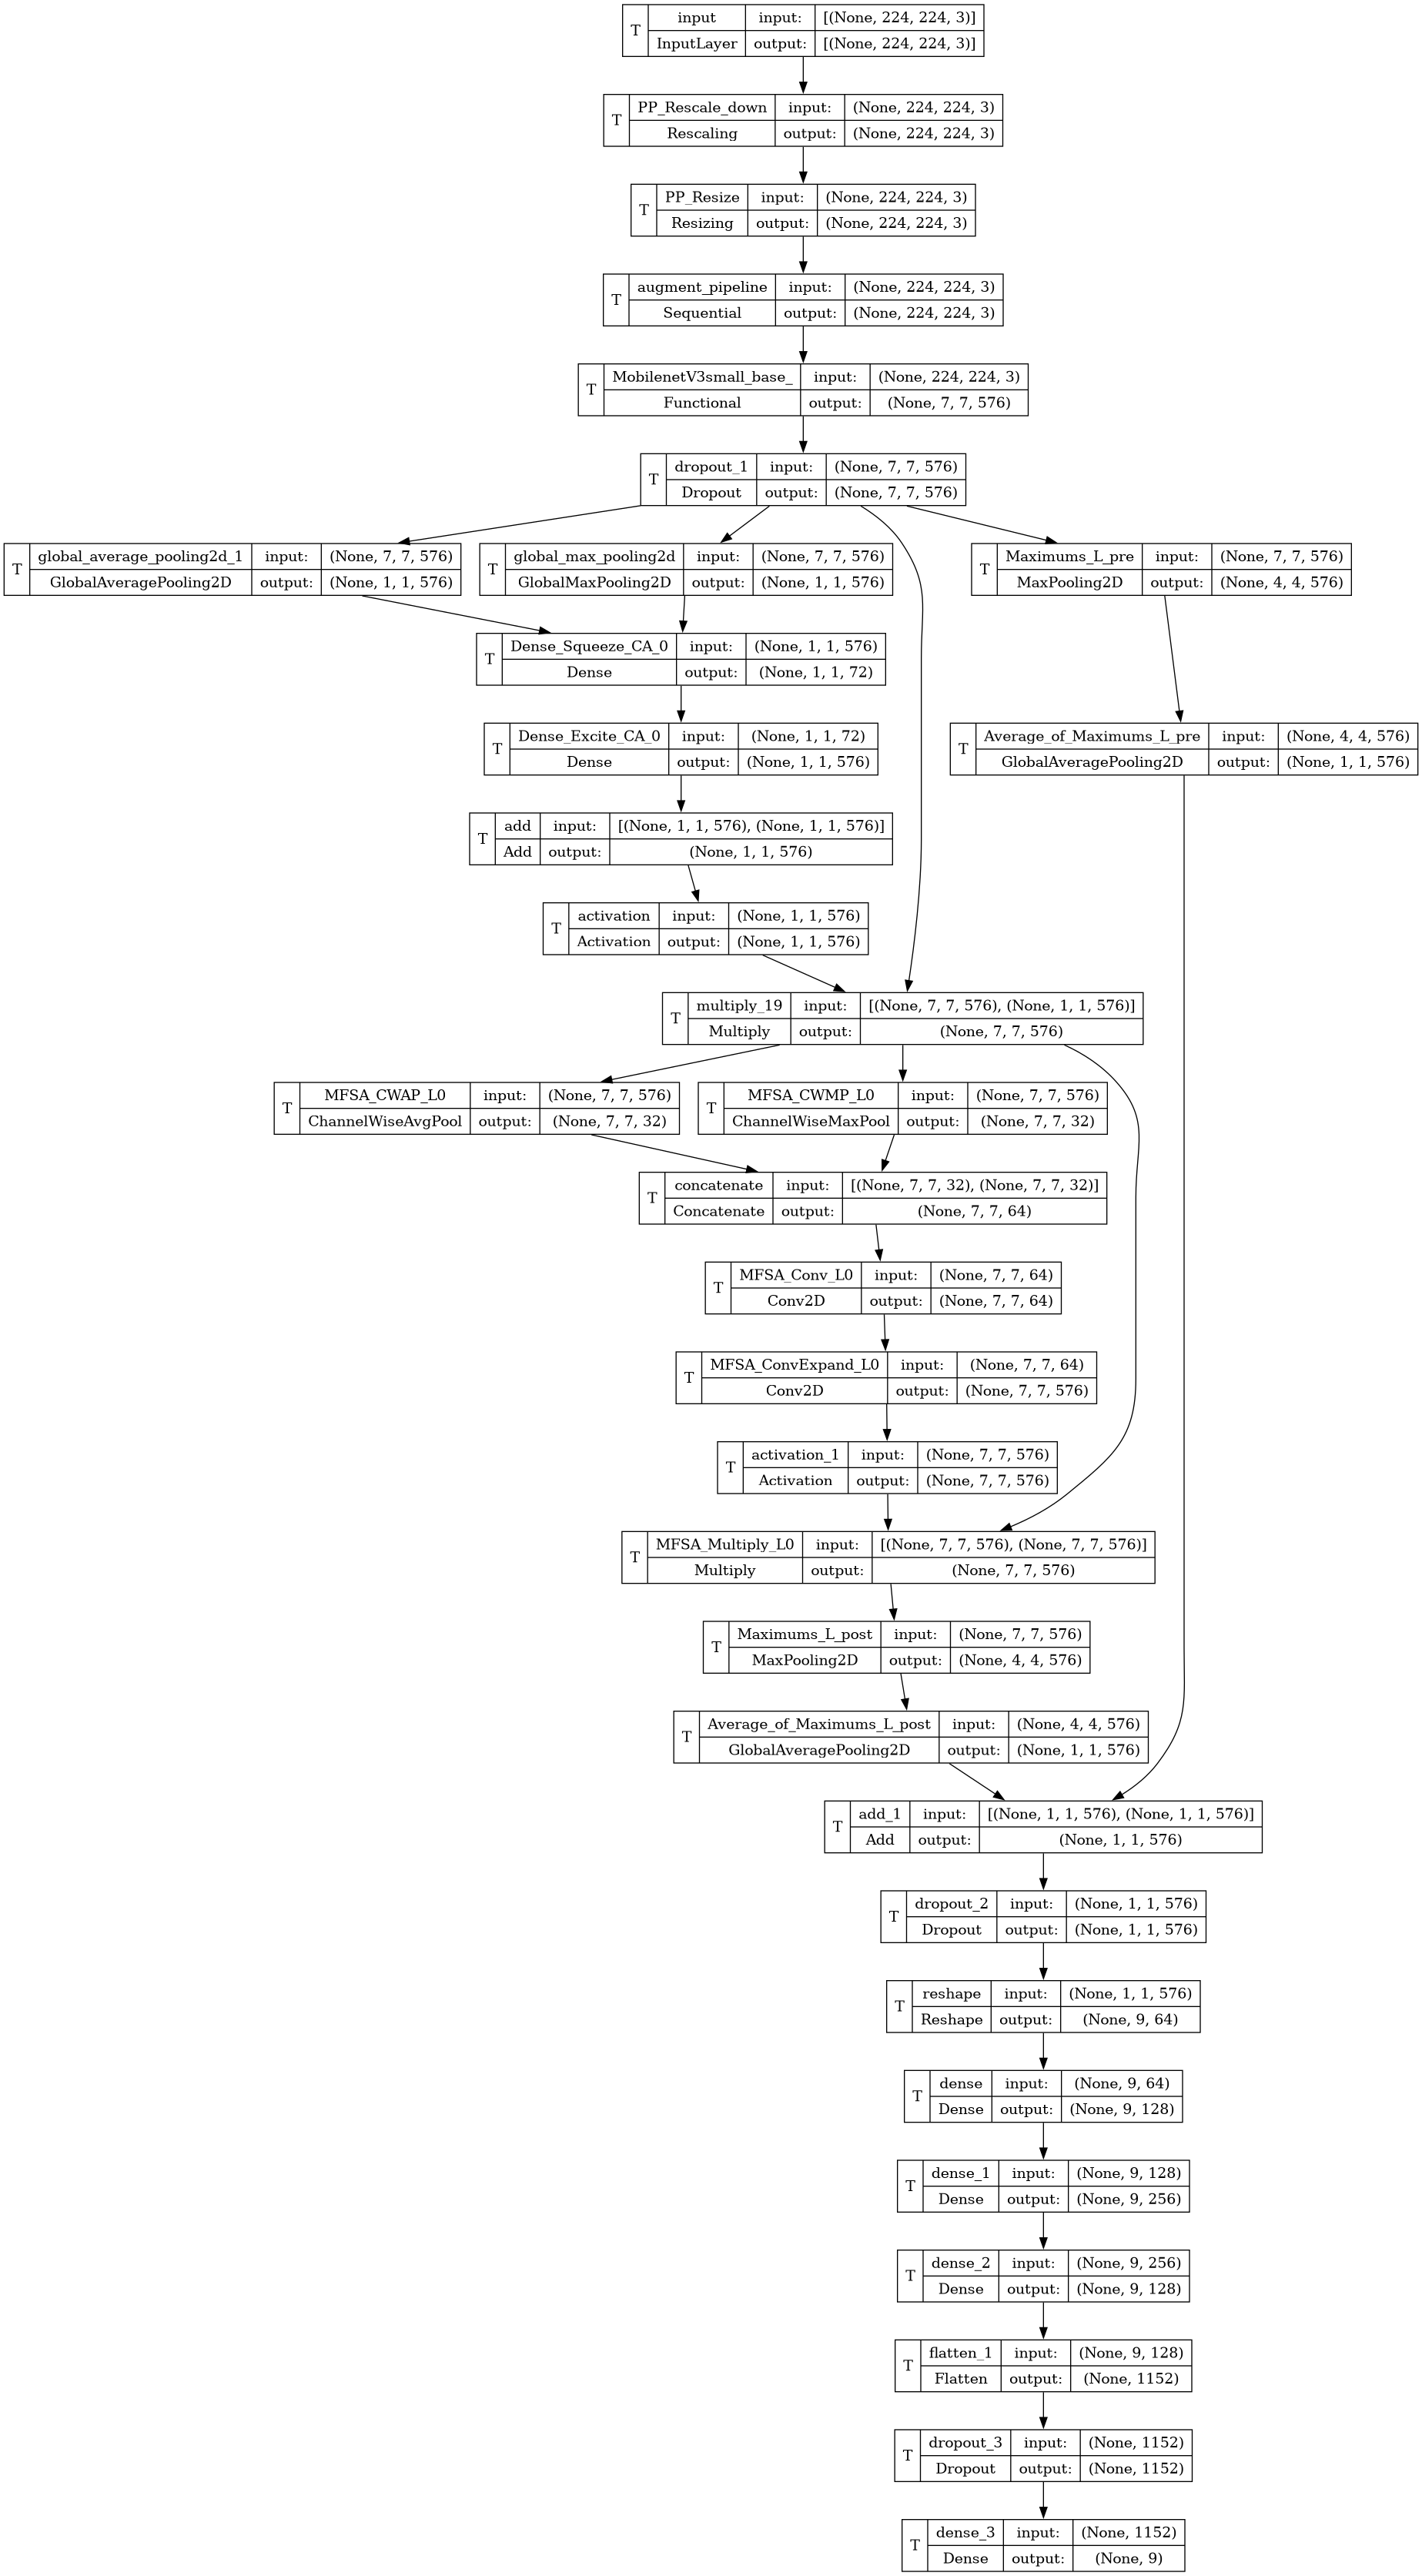

In [20]:
tf.keras.utils.plot_model(model, show_trainable=True, show_layer_names=True, show_shapes=True)

# Trial 1 - FineTuning

In [21]:
from tensorflow.keras.optimizers import Adam, AdamW

early_stopping = tf.keras.callbacks.EarlyStopping(monitor=ES_MONITOR, patience=ES_PATIENCE, verbose=1, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor=LR_REDUCTION_MONITOR,factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=1, min_lr=MIN_LR1)

def scheduler(e, lr):
    if e < WARMUP_EPOCH:
        t = lr + (lr * WARMUP_INCREMENT_RATE)
        return t if t < WARMUP_MAX_LR else WARMUP_MAX_LR
    else:
        return lr
    
warmup = keras.callbacks.LearningRateScheduler(scheduler)
callbacks = [early_stopping, reduce_lr] + ([warmup] if USE_WARMUP else [])

model.compile(loss='categorical_crossentropy',
          optimizer=AdamW(learning_rate=WARMUP_INIT_LR if USE_WARMUP else INIT_LR1,  weight_decay=W_DECAY1),
          metrics=['accuracy'])

model.optimizer.get_config()

{'name': 'AdamW',
 'weight_decay': 0.05,
 'clipnorm': None,
 'global_clipnorm': None,
 'clipvalue': None,
 'use_ema': False,
 'ema_momentum': 0.99,
 'ema_overwrite_frequency': None,
 'jit_compile': True,
 'is_legacy_optimizer': False,
 'learning_rate': 0.0002,
 'beta_1': 0.9,
 'beta_2': 0.999,
 'epsilon': 1e-07,
 'amsgrad': False}

Epoch 1/300


2025-06-15 12:59:05.106740: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDeepWeeds-MobilenetV3small_base_/dropout_1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1749992350.306008     104 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


329/329 [==============================] - 56s 81ms/step - loss: 20.3984 - accuracy: 0.4399 - val_loss: 15.3270 - val_accuracy: 0.5948 - lr: 2.0000e-04
Epoch 2/300
329/329 [==============================] - 25s 75ms/step - loss: 11.7585 - accuracy: 0.5473 - val_loss: 8.2716 - val_accuracy: 0.6436 - lr: 2.0000e-04
Epoch 3/300
329/329 [==============================] - 25s 74ms/step - loss: 6.1903 - accuracy: 0.6016 - val_loss: 4.2539 - val_accuracy: 0.6882 - lr: 2.0000e-04
Epoch 4/300
329/329 [==============================] - 25s 74ms/step - loss: 3.3100 - accuracy: 0.6450 - val_loss: 2.3211 - val_accuracy: 0.7519 - lr: 2.0000e-04
Epoch 5/300
329/329 [==============================] - 25s 75ms/step - loss: 2.0185 - accuracy: 0.6812 - val_loss: 1.5201 - val_accuracy: 0.7693 - lr: 2.0000e-04
Epoch 6/300
329/329 [==============================] - 24s 74ms/step - loss: 1.4346 - accuracy: 0.7147 - val_loss: 1.1207 - val_accuracy: 0.7984 - lr: 2.0000e-04
Epoch 7/300
329/329 [================

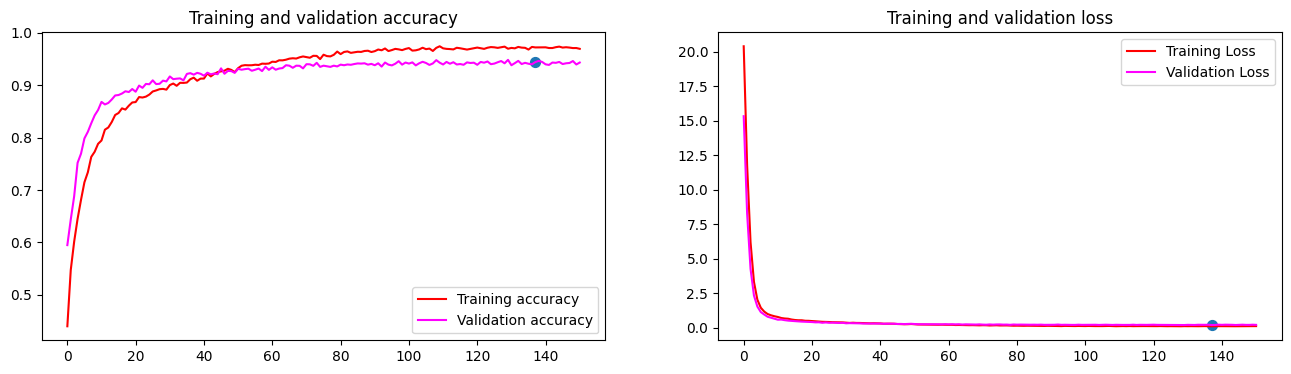

CPU times: user 1h 53min 32s, sys: 6min 22s, total: 1h 59min 54s
Wall time: 1h 2min 45s


In [22]:
%%time

# Train the model
history1 = model.fit(
      train_generator,
      epochs=EPOCHS,
      validation_data=validation_generator,
      callbacks=[early_stopping, reduce_lr, warmup],
    )

print("Saving the Model")
model.save(MODEL_NAME)

# Plot training results
plot_loss_acc(history1.history)

# Evaluation#1

Train Set Statistics
model.evaluate
329/329 [==============================] - 8s 25ms/step - loss: 0.0462 - accuracy: 0.9912
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.97226   0.98521   0.97869       676
       Lantana    0.99042   0.97331   0.98179       637
   Parkinsonia    0.99038   0.99838   0.99437       619
    Parthenium    0.98223   0.99184   0.98701       613
Prickly acacia    0.98423   0.97959   0.98190       637
   Rubber vine    0.99172   0.99008   0.99090       605
     Siam weed    0.99377   0.99068   0.99222       644
    Snake weed    0.98502   0.97049   0.97770       610
      Negative    0.99287   0.99396   0.99341      5463

      accuracy                        0.98962     10504
     macro avg    0.98699   0.98595   0.98645     10504
  weighted avg    0.98964   0.98962   0.98962     10504


                False Positive Rate  Accuracy
Chinee apple               0.001933  0.985207
Lantana                    0.000608  0.973312
Parkinsonia                0.000607  0.998384
Parthenium                 0.001112  0.991843
Prickly acacia    

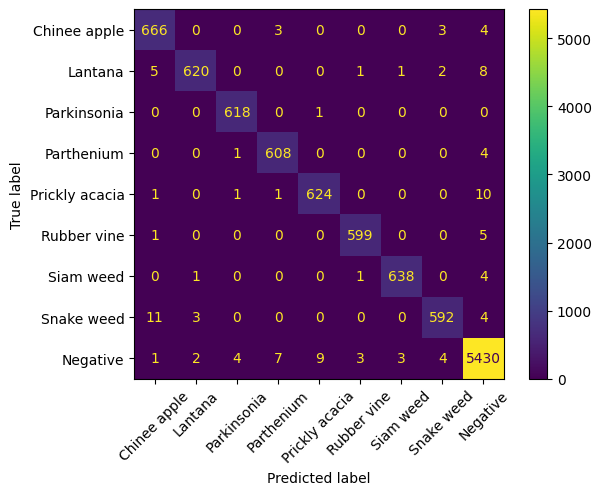


Validation Set Statistics
model.evaluate
110/110 [==============================] - 3s 23ms/step - loss: 0.1898 - accuracy: 0.9426
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.85153   0.86667   0.85903       225
       Lantana    0.91509   0.91080   0.91294       213
   Parkinsonia    0.99010   0.97087   0.98039       206
    Parthenium    0.95545   0.94608   0.95074       204
Prickly acacia    0.92019   0.92453   0.92235       212
   Rubber vine    0.94089   0.94554   0.94321       202
     Siam weed    0.97170   0.95814   0.96487       215
    Snake weed    0.88172   0.80788   0.84319       203
      Negative    0.96093   0.97201   0.96644      1822

      accuracy                        0.94517      3502
     macro avg    0.93195   0.92250   0.92702      3502
  weighted avg    0.94496   0.94517   0.94494      3502


                False Positive Rate  Accuracy
Chinee apple               0.010375  0.866667
Lantana                    0.005473  0.910798
Parkinsonia                0.000607  0.970874
Parthenium                 0.002729  0.946078
Prickly acacia    

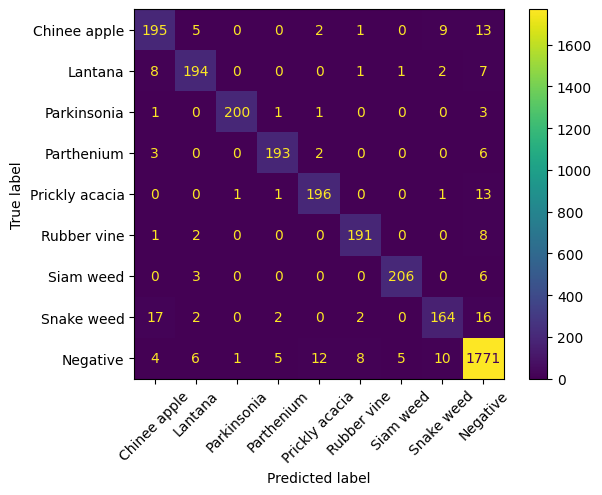


Testn Set Statistics
model.evaluate
110/110 [==============================] - 3s 25ms/step - loss: 4.1393 - accuracy: 0.4727
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.13235   0.08000   0.09972       225
       Lantana    0.17094   0.09390   0.12121       213
   Parkinsonia    0.44737   0.08252   0.13934       206
    Parthenium    0.19118   0.06341   0.09524       205
Prickly acacia    0.17073   0.03286   0.05512       213
   Rubber vine    0.14474   0.05446   0.07914       202
     Siam weed    0.19355   0.08372   0.11688       215
    Snake weed    0.14286   0.06404   0.08844       203
      Negative    0.54133   0.84514   0.65995      1821

      accuracy                        0.47274      3503
     macro avg    0.23723   0.15556   0.16167      3503
  weighted avg    0.37668   0.47274   0.39082      3503


                False Positive Rate  Accuracy
Chinee apple               0.035998  0.080000
Lantana                    0.029483  0.093897
Parkinsonia                0.006369  0.082524
Parthenium                 0.016677  0.063415
Prickly acacia    

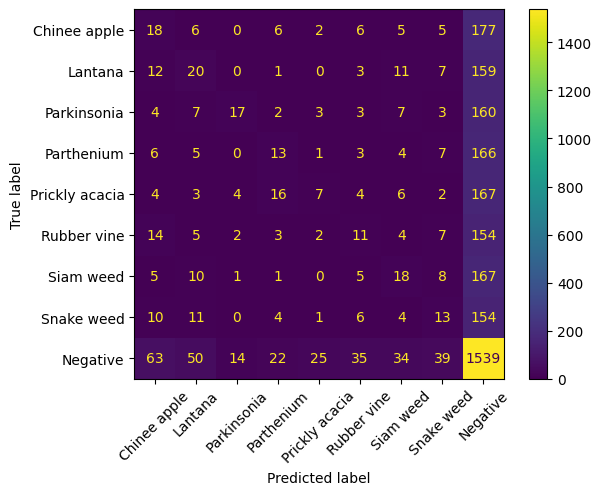

In [23]:
with tf.device(DEVICE):
    print("Train Set Statistics")
    a, b = eval_model(model, train_generator)
    
    print("\nValidation Set Statistics")
    a, b = eval_model(model, validation_generator)
    
    print("\nTestn Set Statistics")
    a, b = eval_model(model, test_generator)

# Trial 2 - Freezing Base Model

In [24]:
for layer in model.layers:
    if 'base' in layer.name.lower():
        print("Freezing Layer", layer.name)
        layer.trainable = False

model.compile(loss='categorical_crossentropy',
          optimizer=AdamW(learning_rate=INIT_LR2,  weight_decay=W_DECAY2),
          metrics=['accuracy'])

model.optimizer.get_config()

Freezing Layer MobilenetV3small_base_


{'name': 'AdamW',
 'weight_decay': 5e-05,
 'clipnorm': None,
 'global_clipnorm': None,
 'clipvalue': None,
 'use_ema': False,
 'ema_momentum': 0.99,
 'ema_overwrite_frequency': None,
 'jit_compile': True,
 'is_legacy_optimizer': False,
 'learning_rate': 2e-05,
 'beta_1': 0.9,
 'beta_2': 0.999,
 'epsilon': 1e-07,
 'amsgrad': False}


Validation Set Statistics
model.evaluate
110/110 [==============================] - 5s 24ms/step - loss: 0.1581 - accuracy: 0.9549
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.89815   0.86222   0.87982       225
       Lantana    0.96172   0.94366   0.95261       213
   Parkinsonia    0.97573   0.97573   0.97573       206
    Parthenium    0.94712   0.96569   0.95631       204
Prickly acacia    0.91705   0.93868   0.92774       212
   Rubber vine    0.94737   0.98020   0.96350       202
     Siam weed    0.93722   0.97209   0.95434       215
    Snake weed    0.86275   0.86700   0.86486       203
      Negative    0.97735   0.97091   0.97412      1822

      accuracy                        0.95488      3502
     macro avg    0.93605   0.94180   0.93878      3502
  weighted avg    0.95497   0.95488   0.95484      3502


                False Positive Rate  Accuracy
Chinee apple               0.006713  0.862222
Lantana                    0.002432  0.943662
Parkinsonia                0.001517  0.975728
Parthenium                 0.003335  0.965686
Prickly acacia    

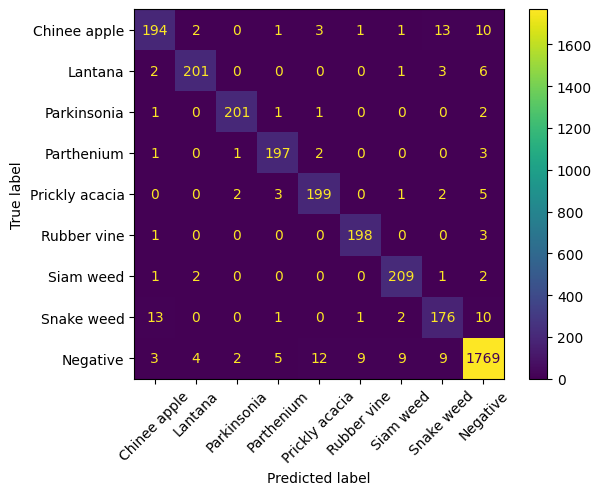

In [25]:
print("\nValidation Set Statistics")
with tf.device(DEVICE):
    a, b = eval_model(model, validation_generator)

model.evaluate
110/110 [==============================] - 3s 23ms/step - loss: 0.1600 - accuracy: 0.9592
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.92273   0.90222   0.91236       225
       Lantana    0.96078   0.92019   0.94005       213
   Parkinsonia    0.96135   0.96602   0.96368       206
    Parthenium    0.95261   0.98049   0.96635       205
Prickly acacia    0.94313   0.93427   0.93868       213
   Rubber vine    0.96970   0.95050   0.96000       202
     Siam weed    0.93213   0.95814   0.94495       215
    Snake weed    0.90686   0.91133   0.90909       203
      Negative    0.97373   0.97694   0.97533      1821

      accuracy                        0.95918      3503
     macro avg    0.94700   0.94445   0.94561      3503
  weighted avg    0.95918   0.95918   0.95911      3503


                False Positive Rate  Accuracy
Chinee apple               0.005186  0.902222
Lantana                    0.002432  0.920188
Parkinsonia                0.002426  0.966019
Parthenium                 0.003032  0.980488
Prickly acacia    

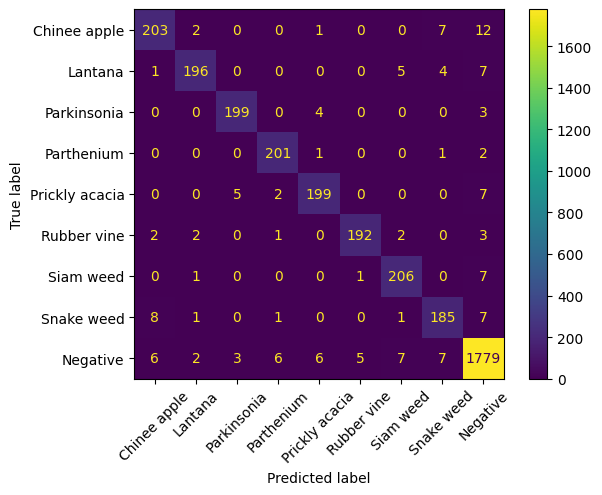

In [26]:
with tf.device(DEVICE):
    ## Test After Freezing
    a, b = eval_model(model, test_generator)

Epoch 1/300


2025-06-15 14:04:23.690943: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDeepWeeds-MobilenetV3small_base_/dropout_1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


329/329 [==============================] - 18s 40ms/step - loss: 0.2015 - accuracy: 0.9400 - val_loss: 0.1766 - val_accuracy: 0.9506 - lr: 2.0000e-05
Epoch 2/300
329/329 [==============================] - 13s 40ms/step - loss: 0.1809 - accuracy: 0.9448 - val_loss: 0.1843 - val_accuracy: 0.9483 - lr: 2.0000e-05
Epoch 3/300
329/329 [==============================] - 13s 39ms/step - loss: 0.1833 - accuracy: 0.9457 - val_loss: 0.1864 - val_accuracy: 0.9472 - lr: 2.0000e-05
Epoch 4/300
327/329 [============================>.] - ETA: 0s - loss: 0.1784 - accuracy: 0.9447
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.5999999595806004e-05.
329/329 [==============================] - 13s 40ms/step - loss: 0.1782 - accuracy: 0.9447 - val_loss: 0.1880 - val_accuracy: 0.9469 - lr: 2.0000e-05
Epoch 5/300
329/329 [==============================] - 13s 40ms/step - loss: 0.1717 - accuracy: 0.9462 - val_loss: 0.1859 - val_accuracy: 0.9486 - lr: 1.6000e-05
Epoch 6/300
329/329 [===================

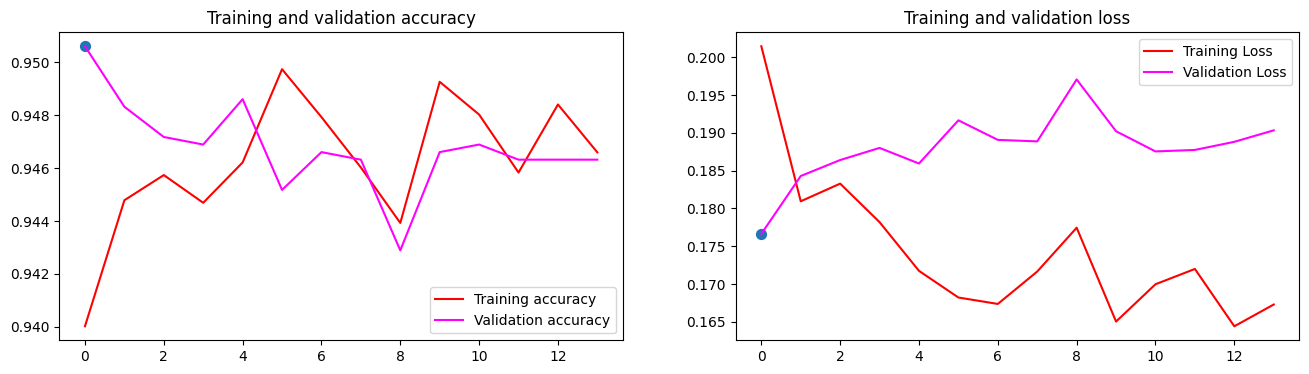

In [27]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor=LR_REDUCTION_MONITOR,factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=LR_REDUCTION_PATIENCE, min_lr=MIN_LR2)

# Train the model
history2 = model.fit(
      train_generator,
      epochs=EPOCHS,
      validation_data=validation_generator,
      callbacks=[early_stopping,reduce_lr]
    )

print("Saving the Model")
model.save(MODEL_NAME)

# Plot training results
plot_loss_acc(history2.history)

# Accuracy / Loss Plots

Total Epochs: range(0, 165)


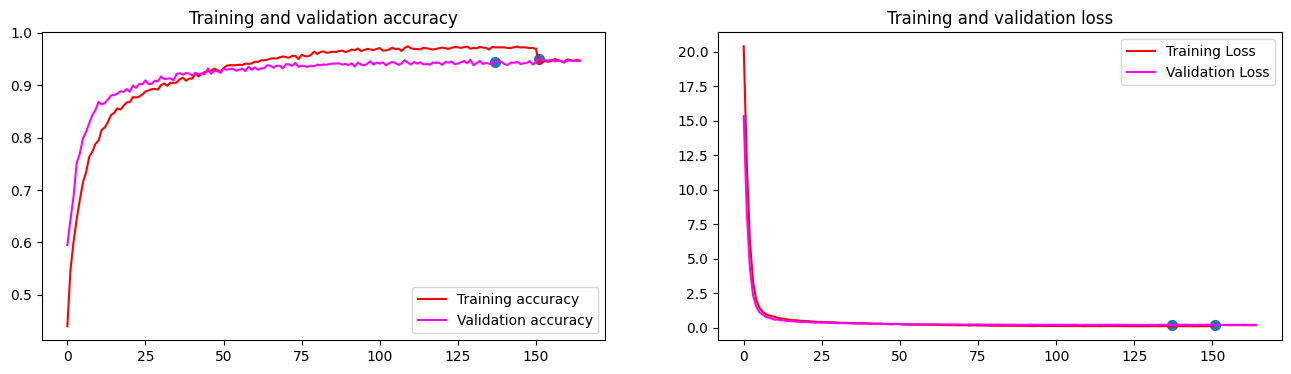

In [28]:
import copy

history = copy.deepcopy(history1.history)

for key in history:
    history[key].extend(history2.history[key])


h1len = len(history1.history['accuracy'])
h2len = len(history2.history['accuracy'])

pat_es = ES_PATIENCE + 1
history['peaks'] = [h1len-pat_es, (h1len+h2len)-pat_es]
history['peaks'] = [i if i>=0 else 0 for i in history['peaks']]

plot_loss_acc(history)

Total Epochs: range(0, 151)


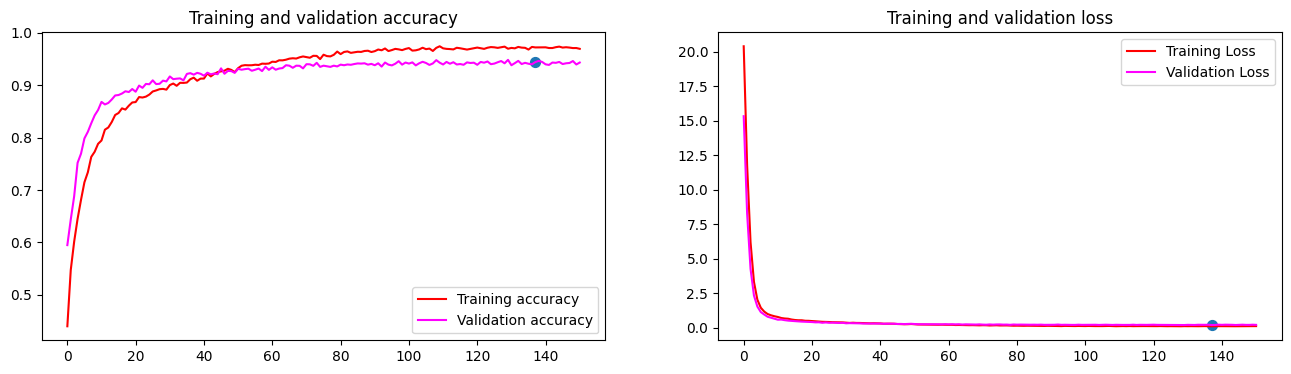

Total Epochs: range(0, 14)


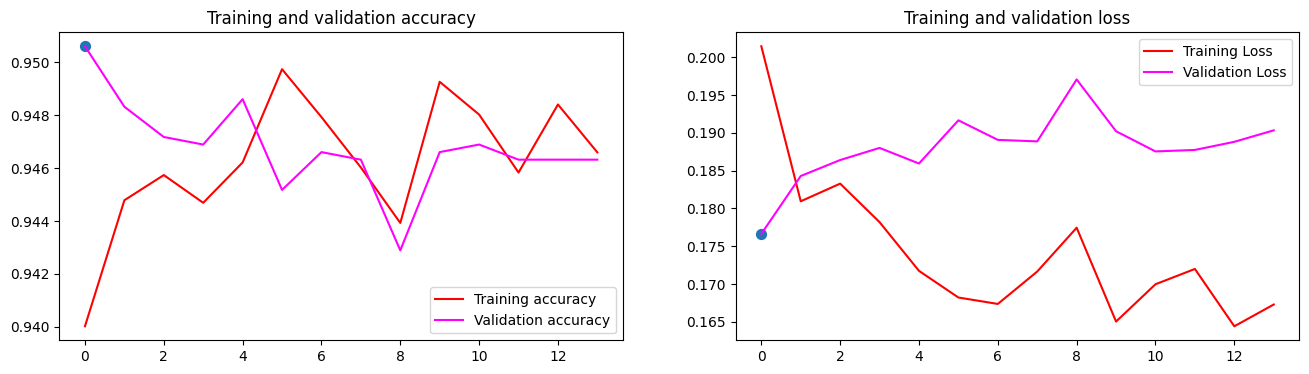

In [29]:
plot_loss_acc(history1.history)
plot_loss_acc(history2.history)

# Evaluation#2

Train Set Statistics
model.evaluate
329/329 [==============================] - 8s 23ms/step - loss: 0.0384 - accuracy: 0.9940
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.99556   0.99556   0.99556       676
       Lantana    0.99843   0.99529   0.99686       637
   Parkinsonia    0.99838   0.99838   0.99838       619
    Parthenium    0.98710   0.99837   0.99270       613
Prickly acacia    0.98903   0.99058   0.98980       637
   Rubber vine    0.99018   1.00000   0.99507       605
     Siam weed    0.96697   1.00000   0.98321       644
    Snake weed    0.98856   0.99180   0.99018       610
      Negative    0.99853   0.99195   0.99522      5463

      accuracy                        0.99400     10504
     macro avg    0.99030   0.99577   0.99300     10504
  weighted avg    0.99408   0.99400   0.99402     10504


                False Positive Rate  Accuracy
Chinee apple               0.000305  0.995562
Lantana                    0.000101  0.995290
Parkinsonia                0.000101  0.998384
Parthenium                 0.000809  0.998369
Prickly acacia    

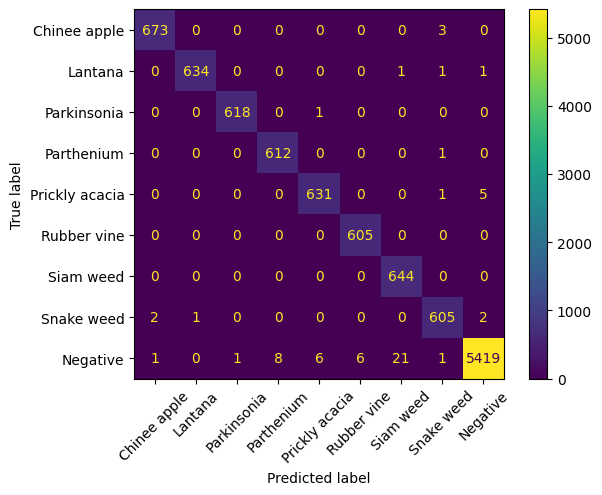


Validation Set Statistics
model.evaluate
110/110 [==============================] - 3s 22ms/step - loss: 0.1766 - accuracy: 0.9506
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.91787   0.84444   0.87963       225
       Lantana    0.94836   0.94836   0.94836       213
   Parkinsonia    0.97573   0.97573   0.97573       206
    Parthenium    0.94712   0.96569   0.95631       204
Prickly acacia    0.90909   0.94340   0.92593       212
   Rubber vine    0.94286   0.98020   0.96117       202
     Siam weed    0.87917   0.98140   0.92747       215
    Snake weed    0.82379   0.92118   0.86977       203
      Negative    0.98419   0.95664   0.97022      1822

      accuracy                        0.95060      3502
     macro avg    0.92535   0.94634   0.93495      3502
  weighted avg    0.95242   0.95060   0.95093      3502


                False Positive Rate  Accuracy
Chinee apple               0.005188  0.844444
Lantana                    0.003344  0.948357
Parkinsonia                0.001517  0.975728
Parthenium                 0.003335  0.965686
Prickly acacia    

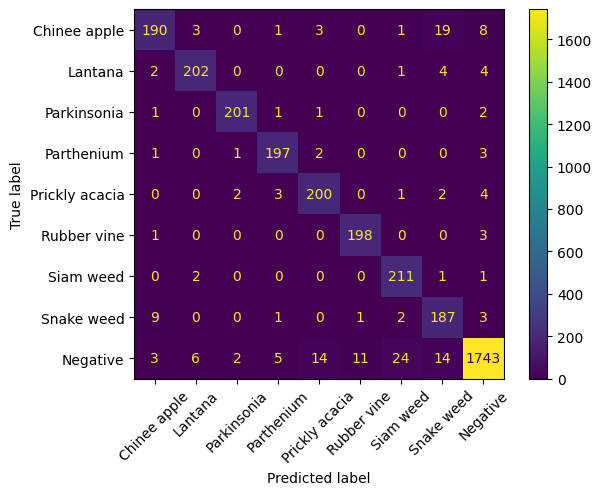


Testn Set Statistics
model.evaluate
110/110 [==============================] - 3s 26ms/step - loss: 0.1708 - accuracy: 0.9563
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.92558   0.88444   0.90455       225
       Lantana    0.95588   0.91549   0.93525       213
   Parkinsonia    0.96135   0.96602   0.96368       206
    Parthenium    0.95261   0.98049   0.96635       205
Prickly acacia    0.93981   0.95305   0.94639       213
   Rubber vine    0.95122   0.96535   0.95823       202
     Siam weed    0.90129   0.97674   0.93750       215
    Snake weed    0.85388   0.92118   0.88626       203
      Negative    0.98215   0.96705   0.97454      1821

      accuracy                        0.95632      3503
     macro avg    0.93598   0.94776   0.94142      3503
  weighted avg    0.95721   0.95632   0.95650      3503


                False Positive Rate  Accuracy
Chinee apple               0.004881  0.884444
Lantana                    0.002736  0.915493
Parkinsonia                0.002426  0.966019
Parthenium                 0.003032  0.980488
Prickly acacia    

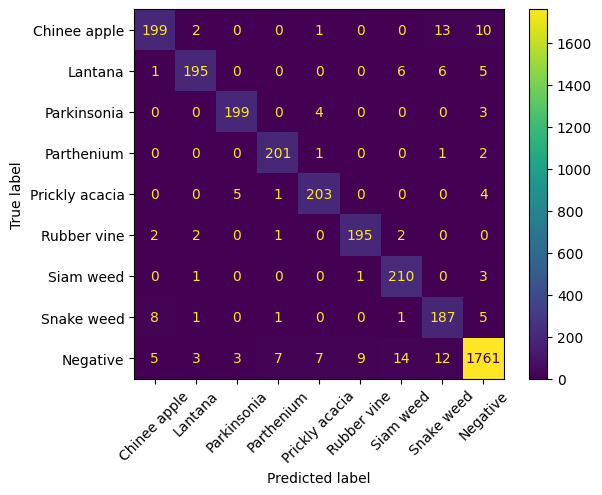

In [30]:
with tf.device(DEVICE):
    print("Train Set Statistics")
    a, b = eval_model(model, train_generator)
    print("\nValidation Set Statistics")
    a, b = eval_model(model, validation_generator)
    print("\nTestn Set Statistics")
    a, b = eval_model(model, test_generator)

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.89778   0.89778   0.89778       225
       Lantana    0.92019   0.92019   0.92019       213
   Parkinsonia    0.96602   0.96602   0.96602       206
    Parthenium    0.95261   0.98049   0.96635       205
Prickly acacia    0.90308   0.96244   0.93182       213
   Rubber vine    0.95098   0.96040   0.95567       202
     Siam weed    0.89744   0.97674   0.93541       215
    Snake weed    0.85000   0.92118   0.88416       203
      Negative    0.98525   0.95387   0.96931      1821

      accuracy                        0.95090      3503
     macro avg    0.92482   0.94879   0.93630      3503
  weighted avg    0.95244   0.95090   0.95128      3503


                False Positive Rate  Accuracy
Chinee apple               0.007016  0.897778
Lantana                    0.005167  0.920188
Parkinsonia                0.002123  0.966019
Parthenium                 0.003032  0.980488
Prickly acacia    

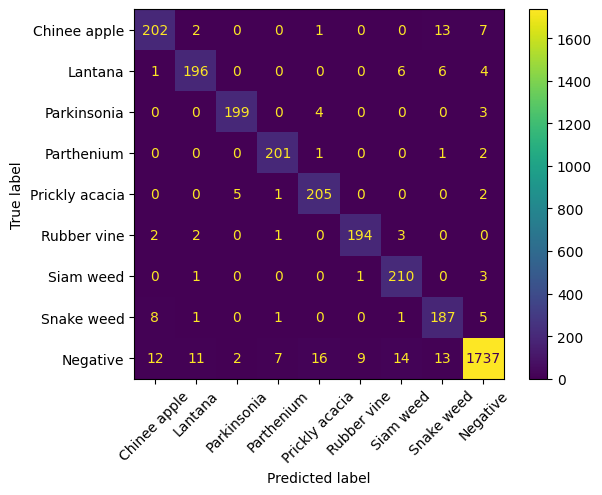

In [31]:
printStats(a,b,0.11)

## Clear Files

In [32]:
shutil.rmtree(base_dir)

In [33]:
# model = buildModel(IMG_SIZE, mtype=MODEL_TYPE, cbam_order=CBAM_ORDER, skip_preprocess=True)
# model.load_weights(MODEL_NAME, skip_mismatch=True)#(model_weights, by_name=True, skip_mismatch=True)
# model.trainable= False
# model.save(model.name+".keras")
# model.summary()

Base Model: MobilenetV3small_base_
228
Model: "DeepWeeds-MobilenetV3small_base_"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 MobilenetV3small_base_ (Fu  (None, 7, 7, 576)            939120    ['input[0][0]']               
 nctional)                                                                                        
                                                                                                  
 dropout_5 (Dropout)         (None, 7, 7, 576)            0         ['MobilenetV3small_base_[0][0]
                                                                    ']                            
                            